Title: wind_height_comparison_plots.ipynb

Purpose: Plot some hubg height data

Author: Onno Nennecke on 10.02.2025 Modified: 23.09.2025

Input data: 

- Wind energy units from the MaStR
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml

Output data:

- Plot: Hub_height_draft
    - This file lies here: /home/onennecke/Code/Figures/

In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Seelage': int(einheit.find('Seelage').text) if einheit.find('Seelage') is not None else np.nan,
            # 'ClusterNordsee': int(einheit.find('ClusterNordsee').text) if einheit.find('ClusterNordsee') is not None else np.nan,
            # 'ClusterOstsee': int(einheit.find('ClusterOstsee').text) if einheit.find('ClusterOstsee') is not None else np.nan,
            'Wassertiefe': float(einheit.find('Wassertiefe').text) if einheit.find('Wassertiefe') is not None else np.nan,
            'Kuestenentfernung': float(einheit.find('Kuestenentfernung').text) if einheit.find('Kuestenentfernung') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
print(df)

      EinheitMastrNummer  Bruttoleistung  Nettonennleistung   Lage  \
0        SEE940146675093          3000.0             3000.0  888.0   
1        SEE973767078653          3000.0             3000.0  888.0   
2        SEE914108319653          3000.0             3000.0  888.0   
3        SEE982417853618          3000.0             3000.0  888.0   
4        SEE913741454097          2400.0             2400.0  888.0   
...                  ...             ...                ...    ...   
38070    SEE938428285726          3500.0             3500.0  888.0   
38071    SEE987122644452          3500.0             3500.0  888.0   
38072    SEE924447498896          3500.0             3500.0  888.0   
38073    SEE938294352034          4200.0             4200.0  888.0   
38074    SEE987180399516          7200.0             7200.0  888.0   

                  NameWindpark  Nabenhoehe  Rotordurchmesser  Seelage  \
0          Windpark Kreuzstein      149.08            115.71      NaN   
1            

In [4]:
# Drop closed units
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb
# df_1[df_1['Lage'].isna()]

# Add some missing values
df_1.loc[df_1['Lage'].isna(), 'Lage'] = 888


In [5]:
print(df_1[df_1['Lage'] == 889]['Nabenhoehe'].mean()) # Offshore
print(df_1[df_1['Lage'] != 889]['Nabenhoehe'].mean()) # Onshore
print(df_1['Nabenhoehe'].mean())
print(df_1[df_1['Lage'] == 889]['Nabenhoehe'].describe()) # Offshore
print(df_1[df_1['Lage'] != 889]['Nabenhoehe'].describe()) # Onshore


96.10388198757764
98.61327488119018
98.48145151396501
count    1610.000000
mean       96.103882
std        10.063147
min        67.000000
25%        90.000000
50%        92.990000
75%       104.500000
max       126.500000
Name: Nabenhoehe, dtype: float64
count    29038.000000
mean        98.613275
std         35.038866
min          1.000000
25%         70.000000
50%         98.350000
75%        135.000000
max        173.480000
Name: Nabenhoehe, dtype: float64


In [6]:
df_1['Lage'] = df_1['Lage'].replace({889: 'Offshore', 888: 'Onshore'})
# set(df_1['Lage'])

In [7]:
def weighted_mean(df, value_column, weight_column):
    return np.average(df[value_column], weights=df[weight_column])

df_2 = df_1.dropna(subset=['Nabenhoehe'])

In [8]:
df_2[df_2['Lage'] == 'Offshore']

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,Lage,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad,EinheitBetriebsstatus
223,SEE991181426935,6300.0,6300.0,Offshore,OWP Veja Mate,103.28,154.0,640.0,39.8,63.923,5.828958,54.341550,35
303,SEE948492783349,3780.0,3780.0,Offshore,OWP DanTysk,88.00,120.0,640.0,29.8,50.570,7.174499,55.067578,35
338,SEE996261343003,3780.0,3780.0,Offshore,OWP DanTysk,88.00,120.0,640.0,28.7,50.650,7.175124,55.075620,35
623,SEE990582178207,3780.0,3780.0,Offshore,Baltic 2,78.25,120.0,639.0,42.6,30.740,13.083867,54.949617,35
627,SEE969452881615,3780.0,3780.0,Offshore,Baltic 2,78.25,120.0,639.0,42.0,31.230,13.092806,54.957388,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34289,SEE982413596991,11550.0,11550.0,Offshore,Gode Wind 3,126.50,200.0,640.0,30.2,22.200,7.096548,54.030592,35
34290,SEE905373051485,11550.0,11550.0,Offshore,Gode Wind 3,126.50,200.0,640.0,29.9,22.000,7.085100,54.023670,35
34291,SEE942700031529,11550.0,11550.0,Offshore,Gode Wind 3,126.50,200.0,640.0,29.5,21.700,7.073857,54.016865,35
34292,SEE980736061066,11550.0,11550.0,Offshore,Gode Wind 3,126.50,200.0,640.0,29.0,21.500,7.063277,54.010465,35


In [9]:
df_2[df_2['Lage'] == 'Onshore']

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,Lage,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad,EinheitBetriebsstatus
0,SEE940146675093,3000.0,3000.0,Onshore,Windpark Kreuzstein,149.08,115.710,NaN,NaN,NaN,9.739374,51.270068,35
1,SEE973767078653,3000.0,3000.0,Onshore,Damsdorf,135.40,115.700,NaN,NaN,NaN,10.299400,54.073831,35
2,SEE914108319653,3000.0,3000.0,Onshore,Windpark Kreuzstein,149.08,115.710,NaN,NaN,NaN,9.733069,51.272164,35
3,SEE982417853618,3000.0,3000.0,Onshore,Windpark Kreuzstein,149.08,115.710,NaN,NaN,NaN,9.748361,51.270462,35
4,SEE913741454097,2400.0,2400.0,Onshore,Windpark Heinsberg Pütt,120.00,116.800,NaN,NaN,NaN,6.045546,51.029548,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37722,SEE925893699196,10.0,10.0,Onshore,Butjadingen privat,8.00,4.400,NaN,NaN,NaN,NaN,NaN,35
37747,SEE961246009564,1.0,1.0,Onshore,WKA SkyWind Auritz,7.00,1.509,NaN,NaN,NaN,NaN,NaN,35
37940,SEE965066246611,0.6,0.6,Onshore,Kleinwindrad 2024 Zeppelinstraße,8.00,1.510,NaN,NaN,NaN,NaN,NaN,35
38028,SEE945872382253,1.0,1.0,Onshore,Westwind,3.40,2.100,NaN,NaN,NaN,NaN,NaN,35


In [10]:
print(df_2[df_2['Lage'] == 'Onshore']['Bruttoleistung'].sum() / 1000000) # in GW
print(df_2[df_2['Lage'] == 'Onshore']['Bruttoleistung'].sum() / 1000) # in MW
print(df_2[df_2['Lage'] == 'Onshore']['Bruttoleistung'].sum()) # in kW


62.554602577999994
62554.60257799999
62554602.577999994


In [11]:
df_3 = df_2.copy()
df_3['Bruttoleistung'] = df_2['Bruttoleistung']/ 1000
df_3['Nettonennleistung'] = df_2['Nettonennleistung']/ 1000
df_3

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,Lage,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad,EinheitBetriebsstatus
0,SEE940146675093,3.0000,3.0000,Onshore,Windpark Kreuzstein,149.08,115.710,NaN,NaN,NaN,9.739374,51.270068,35
1,SEE973767078653,3.0000,3.0000,Onshore,Damsdorf,135.40,115.700,NaN,NaN,NaN,10.299400,54.073831,35
2,SEE914108319653,3.0000,3.0000,Onshore,Windpark Kreuzstein,149.08,115.710,NaN,NaN,NaN,9.733069,51.272164,35
3,SEE982417853618,3.0000,3.0000,Onshore,Windpark Kreuzstein,149.08,115.710,NaN,NaN,NaN,9.748361,51.270462,35
4,SEE913741454097,2.4000,2.4000,Onshore,Windpark Heinsberg Pütt,120.00,116.800,NaN,NaN,NaN,6.045546,51.029548,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37722,SEE925893699196,0.0100,0.0100,Onshore,Butjadingen privat,8.00,4.400,NaN,NaN,NaN,NaN,NaN,35
37747,SEE961246009564,0.0010,0.0010,Onshore,WKA SkyWind Auritz,7.00,1.509,NaN,NaN,NaN,NaN,NaN,35
37940,SEE965066246611,0.0006,0.0006,Onshore,Kleinwindrad 2024 Zeppelinstraße,8.00,1.510,NaN,NaN,NaN,NaN,NaN,35
38028,SEE945872382253,0.0010,0.0010,Onshore,Westwind,3.40,2.100,NaN,NaN,NaN,NaN,NaN,35


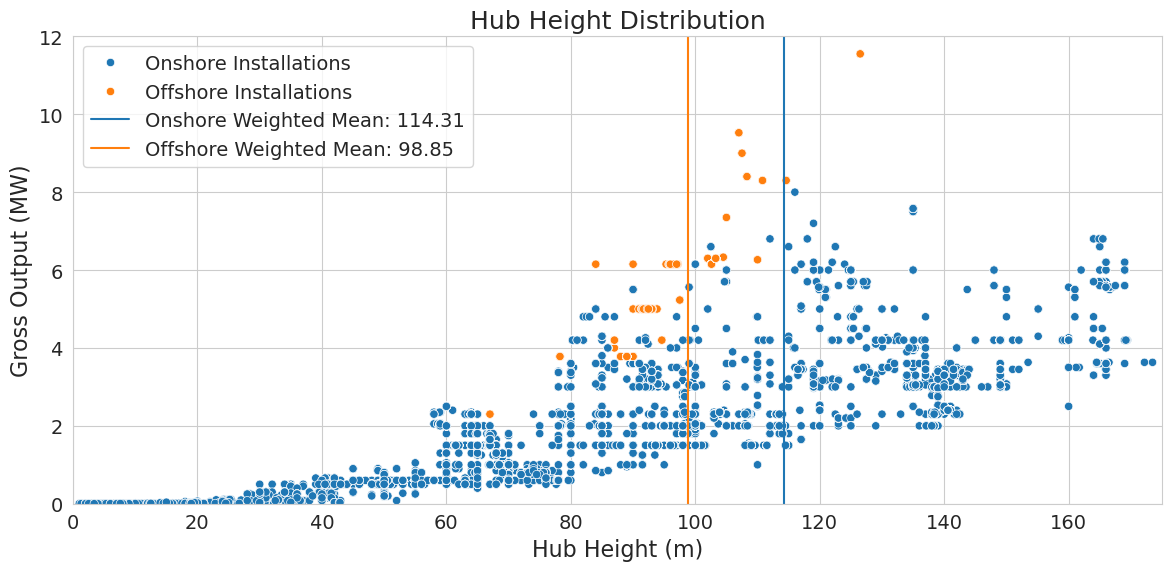

In [ ]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# Scatterplot
sns.scatterplot(
    data=df_3, x='Nabenhoehe', y='Bruttoleistung', hue='Lage'
)

# Means
mean_onshore = df_3[df_3['Lage'] == 'Onshore']['Nabenhoehe'].mean()
mean_offshore = df_3[df_3['Lage'] == 'Offshore']['Nabenhoehe'].mean()
weighted_mean_onshore = weighted_mean(df_3[df_3['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung')
weighted_mean_offshore = weighted_mean(df_3[df_3['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung')

# Vertical lines
# plt.axvline(mean_onshore, color='blue', linestyle='--',
#             label=f'Onshore Mean: {mean_onshore:.2f}')
plt.axvline(weighted_mean_onshore, color="#1f77b4", linestyle='-',
            label=f'Onshore Weighted Mean: {weighted_mean_onshore:.2f}')
# plt.axvline(mean_offshore, color='red', linestyle='--',
#             label=f'Offshore Mean: {mean_offshore:.2f}')
plt.axvline(weighted_mean_offshore, color="#ff7f0e", linestyle='-',
            label=f'Offshore Weighted Mean: {weighted_mean_offshore:.2f}')

# Labels & title with larger fonts
plt.xlabel('Hub Height (m)', fontsize=16)
plt.ylabel('Gross Output (MW)', fontsize=16)
plt.title('Hub Height Distribution', fontsize=18) #, fontweight='bold')

# Limits
plt.xlim(0, 175)
plt.ylim(0, 12)

# Bigger ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend bigger
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Onshore Installations' if lbl == 'Onshore' else 'Offshore Installations' if lbl == 'Offshore' else lbl for lbl in labels]
plt.legend(handles, labels, loc='upper left', fontsize=14, title_fontsize=18)


plt.tight_layout()

# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Hub_height_sctr.png', dpi=300, bbox_inches='tight')

plt.show()


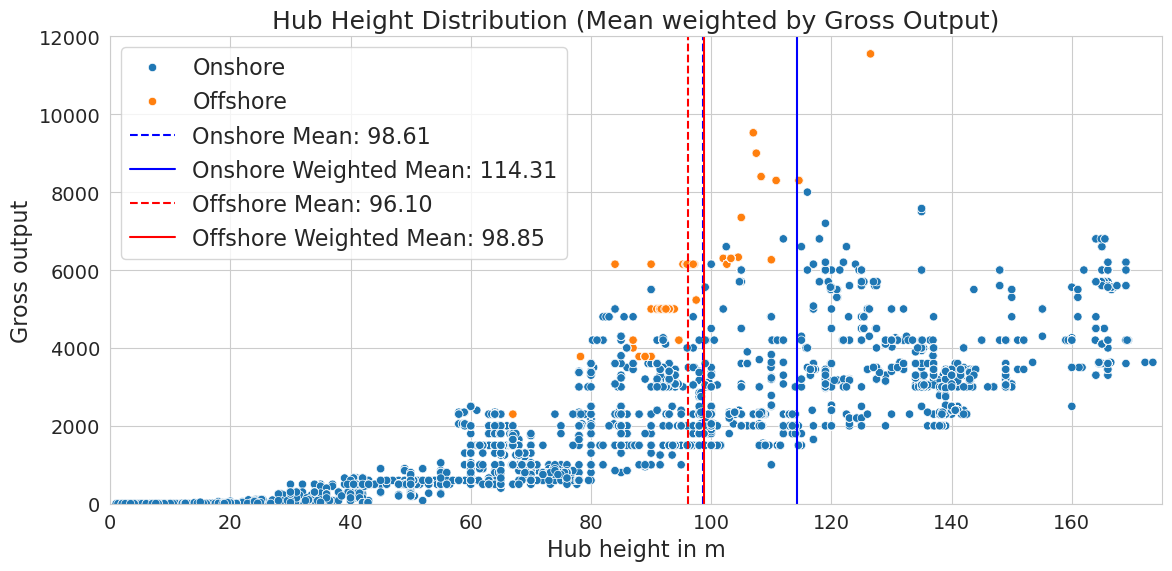

In [13]:
# Old plot
# Plot the height distribution coloured by the Lage
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_2, x='Nabenhoehe', y='Bruttoleistung', hue='Lage')
mean_onshore = df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean()
mean_offshore = df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean()
weighted_mean_onshore = weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung')
weighted_mean_offshore = weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung')

plt.axvline(mean_onshore, color='blue', linestyle='--', label=f'Onshore Mean: {mean_onshore:.2f}')
plt.axvline(weighted_mean_onshore, color='blue', linestyle='-', label=f'Onshore Weighted Mean: {weighted_mean_onshore:.2f}')
plt.axvline(mean_offshore, color='red', linestyle='--', label=f'Offshore Mean: {mean_offshore:.2f}')
plt.axvline(weighted_mean_offshore, color='red', linestyle='-', label=f'Offshore Weighted Mean: {weighted_mean_offshore:.2f}')
plt.xlabel('Hub height in m')
plt.xlim(0, 175)
plt.ylim(0, 12000)
plt.ylabel('Gross output')
plt.legend(loc='upper left')
plt.title('Hub Height Distribution (Mean weighted by Gross Output)')

plt.tight_layout()

# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Hub_height_draft.png', dpi=300, bbox_inches='tight')

plt.show()


In [14]:
print('Onshore: \n', df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].describe())
print(weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung'))
print('Onshore: \n', df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].describe())
print(weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung'))


Onshore: 
 count    29038.000000
mean        98.613275
std         35.038866
min          1.000000
25%         70.000000
50%         98.350000
75%        135.000000
max        173.480000
Name: Nabenhoehe, dtype: float64
114.31232198057913
Onshore: 
 count    1610.000000
mean       96.103882
std        10.063147
min        67.000000
25%        90.000000
50%        92.990000
75%       104.500000
max       126.500000
Name: Nabenhoehe, dtype: float64
98.84774531314085


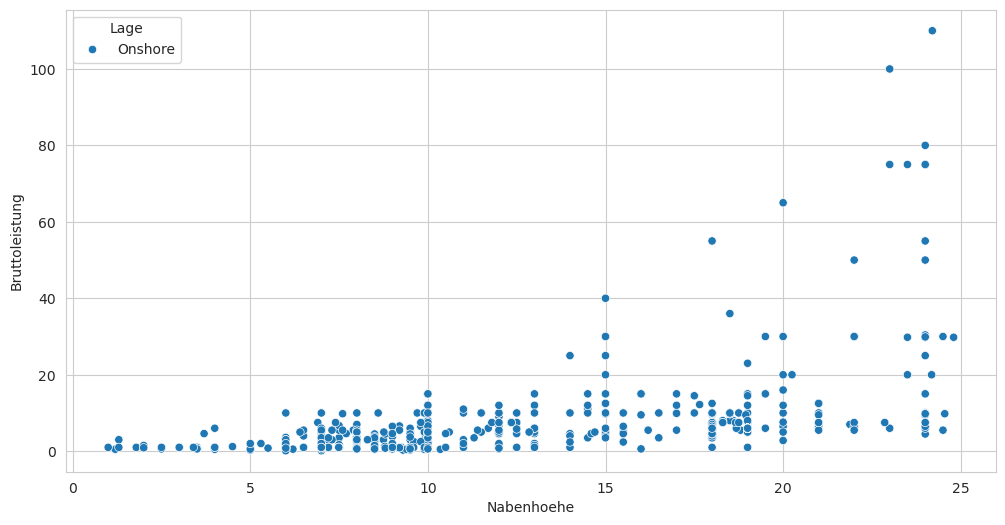

In [10]:
# Just out of curiosity plot the low power wind installations

# df_1['Nabenhoehe' < 25]['Bruttoleistung'].describe()
df_3 = df_1[df_1['Nabenhoehe'] < 25].copy()
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_3, x='Nabenhoehe', y='Bruttoleistung', hue='Lage')
# sns.scatterplot(data=df_1, x='Lage', y='Nabenhoehe')

plt.show()

---------------------------------------------------------------------------

### Old code with unweighted hub height

In [12]:
# Open all height datasets

# grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height.nc')
# grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height.nc')
grid_offshore_weighted = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
grid_onshore_weighted = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
#rename data variable
grid_offshore_weighted = grid_offshore_weighted.rename_vars({'wind_off_hub_height': 'wind_off_hub_height_weighted'})
grid_onshore_weighted = grid_onshore_weighted.rename_vars({'wind_on_hub_height': 'wind_on_hub_height_weighted'})

In [13]:
# Load installed capacity data
grid_offshore_ic = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_onshore_ic = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')

In [14]:
# Combine the offshore data
# grid_offshore_combined = xr.merge([grid_offshore, grid_offshore_weighted, grid_offshore_ic])

# # Combine the onshore data
# grid_onshore_combined = xr.merge([grid_onshore, grid_onshore_weighted, grid_onshore_ic])

In [15]:
print('Offshore:')
# print('Gridded, not weighted: ', grid_offshore_combined['wind_off_hub_height'].mean().values)
# print('Gridded, Weighted: ', grid_offshore_combined['wind_off_hub_height_weighted'].mean().values)
print('Original, not Weighted: ', df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean())
print('Original, Weighted: ', weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung'))

print('Onshore:')
# print('Gridded, not weighted: ', grid_onshore_combined['wind_on_hub_height'].mean().values)
# print('Gridded, Weighted: ', grid_onshore_combined['wind_on_hub_height_weighted'].mean().values)
print('Original, not Weighted: ', df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean())
print('Original, Weighted: ', weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung'))

Offshore:
Original, not Weighted:  96.10388198757764
Original, Weighted:  98.84774531314085
Onshore:
Original, not Weighted:  98.61327488119015
Original, Weighted:  114.31232198057913


In [ ]:
print('Offshore:')
# print('Gridded, not weighted: ', grid_offshore_combined['wind_off_hub_height'].mean().values)
# print('Gridded, Weighted: ', grid_offshore_combined['wind_off_hub_height_weighted'].mean().values)
print('Original, not Weighted: ', df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean())
print('Original, Weighted: ', weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung'))

print('Onshore:')
# print('Gridded, not weighted: ', grid_onshore_combined['wind_on_hub_height'].mean().values)
# print('Gridded, Weighted: ', grid_onshore_combined['wind_on_hub_height_weighted'].mean().values)
print('Original, not Weighted: ', df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean())
print('Original, Weighted: ', weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung'))

Offshore:
Gridded, not weighted:  92.75319279891357
Gridded, Weighted:  93.94674949553115
Original, not Weighted:  96.10388198757764
Original, Weighted:  98.84774531314085
Onshore:
Gridded, not weighted:  85.66859123135976
Gridded, Weighted:  113.71185462978931
Original, not Weighted:  98.61327488119015
Original, Weighted:  114.31232198057913


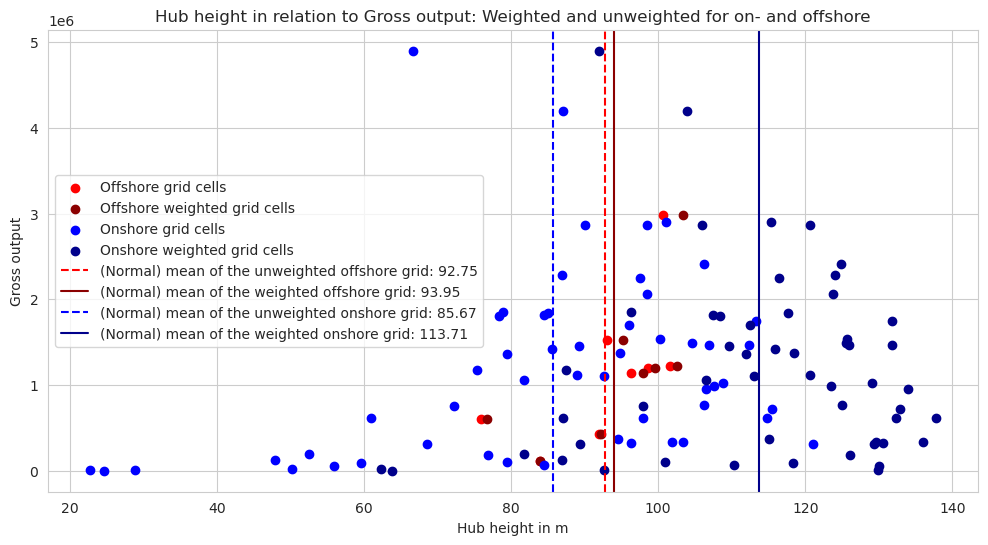

In [ ]:
# Plot all data in one scatterplot (height against capacity) on and offshore labeled by colour
plt.figure(figsize=(12, 6))
plt.scatter(grid_offshore_combined['wind_off_hub_height'], grid_offshore_combined['wind_off_cap'], label='Offshore grid cells', color='red')
plt.scatter(grid_offshore_combined['wind_off_hub_height_weighted'], grid_offshore_combined['wind_off_cap'], label='Offshore weighted grid cells', color='darkred')

plt.scatter(grid_onshore_combined['wind_on_hub_height'], grid_onshore_combined['wind_on_cap'], label='Onshore grid cells', color='blue')
plt.scatter(grid_onshore_combined['wind_on_hub_height_weighted'], grid_onshore_combined['wind_on_cap'], label='Onshore weighted grid cells', color='darkblue')
mean_onshore = grid_onshore_combined['wind_on_hub_height'].mean().values # df_2[df_2['Lage'] == 'Onshore']['Nabenhoehe'].mean()
mean_offshore = grid_offshore_combined['wind_off_hub_height'].mean().values # df_2[df_2['Lage'] == 'Offshore']['Nabenhoehe'].mean()
weighted_mean_onshore = grid_onshore_combined['wind_on_hub_height_weighted'].mean().values # weighted_mean(df_2[df_2['Lage'] == 'Onshore'], 'Nabenhoehe', 'Bruttoleistung')
weighted_mean_offshore = grid_offshore_combined['wind_off_hub_height_weighted'].mean().values # weighted_mean(df_2[df_2['Lage'] == 'Offshore'], 'Nabenhoehe', 'Bruttoleistung')

# plt.axvline(mean_offshore, color='red', linestyle='--', label=f'Offshore Mean: {mean_offshore:.2f}')
# plt.axvline(weighted_mean_offshore, color='darkred', linestyle='-', label=f'Offshore Weighted Mean: {weighted_mean_offshore:.2f}')
# plt.axvline(mean_onshore, color='blue', linestyle='--', label=f'Onshore Mean: {mean_onshore:.2f}')
# plt.axvline(weighted_mean_onshore, color='darkblue', linestyle='-', label=f'Onshore Weighted Mean: {weighted_mean_onshore:.2f}')

plt.axvline(mean_offshore, color='red', linestyle='--', label=f'(Normal) mean of the unweighted offshore grid: {mean_offshore:.2f}')
plt.axvline(weighted_mean_offshore, color='darkred', linestyle='-', label=f'(Normal) mean of the weighted offshore grid: {weighted_mean_offshore:.2f}')
plt.axvline(mean_onshore, color='blue', linestyle='--', label=f'(Normal) mean of the unweighted onshore grid: {mean_onshore:.2f}')
plt.axvline(weighted_mean_onshore, color='darkblue', linestyle='-', label=f'(Normal) mean of the weighted onshore grid: {weighted_mean_onshore:.2f}')

plt.xlabel('Hub height in m')
plt.ylabel('Gross output')
plt.legend()
plt.title('Hub height in relation to Gross output: Weighted and unweighted for on- and offshore')
plt.show()